In [ ]:
# ! pip install google-cloud-aiplatform vertexai

In [2]:
from typing import Sequence
import dataclasses
import json
from vertexai import generative_models

GENERATION_AUTORATER_EVAL_PROMPT_WITH_IMAGES = """
You are an evaluation expert. You will be provided with a query, a generated response and a ground truth. Your task is to analyze the generated response for accuracy, completeness, and relevance compared to the ground truth.
You may also be given with images that provided by generated response or ground truth, in this case, you also need to evaluate if the generated response images are relevant to the ground truth results.

Please provide:
A float score from 0 to 5, where 0 is completely inaccurate and 5 is perfectly accurate.
A detailed explanation of why you gave that score, highlighting specific areas where the generated response was correct, incorrect, missing information, or irrelevant.
The output should be in JSON format.

EXAMPLE:

Query: What's the Capital of China
Generated Response: Victoria.
Ground Truth: Beijing

EVALUATION
{
"score" : 0.0,
"reason" : "The generated response is incorrect based on provided ground truth."
}
"""

RESPONSE_SCHEMA_SCORE = {
    "type": "object",
    "properties": {
        "score": {"type": "number", "minimum": 0, "maximum": 5},
        "reason": {"type": "string"},
    },
    "required": ["score", "reason"],
}


@dataclasses.dataclass(frozen=True)
class GenerationEvaluation:
  """The generation evaluation result.

  Attributes:
    score: The score of the generation evaluation.
    reason: The reason of the generation evaluation.
  """
  score: float
  reason: str


def eval_generation(
    autorater_model: generative_models.GenerativeModel,
    question: Sequence[generative_models.Part],
    model_reply: Sequence[generative_models.Part],
    ground_truth: Sequence[generative_models.Part],
) -> GenerationEvaluation:
  """Evaluates the generated response for accuracy, completeness, and relevance compared to the ground truth.

  Args:
    autorater_model: The autorater model to use.
    question: The question to ask the model.
    model_reply: The model's reply to the question.
    ground_truth: The ground truth answer to the question.

  Returns:
    The generation evaluation result.
  """
  part_list = []
  part_list.append(
      generative_models.Part.from_text(
          GENERATION_AUTORATER_EVAL_PROMPT_WITH_IMAGES
      )
  )

  part_list.append(generative_models.Part.from_text("\nQuery: "))
  for part in question:
    part_list.append(part)

  part_list.append(generative_models.Part.from_text("\nGenerated Response: "))
  for part in model_reply:
    part_list.append(part)

  part_list.append(generative_models.Part.from_text("\nGround Truth: "))
  for part in ground_truth:
    part_list.append(part)

  response: generative_models.GenerationResponse = (
      autorater_model.generate_content(
          part_list,
          generation_config=generative_models.GenerationConfig(
              temperature=0,
              response_mime_type="application/json",
              response_schema=RESPONSE_SCHEMA_SCORE,
          ),
      )
  )
  score_eval_response_dict = json.loads(response.candidates[0].text)
  eval_result = GenerationEvaluation(
      score=score_eval_response_dict["score"],
      reason=score_eval_response_dict["reason"],
  )
  return eval_result

In [26]:
import vertexai
vertexai.init(project="ivanmkc-experimental-2-631260")

In [27]:
import asyncio
from async_lru import alru_cache

model_name = "gemini-2.5-flash"
model: generative_models.GenerativeModel = generative_models.GenerativeModel(
    model_name=model_name,
)

question = "What is the capital of Canada"
model_reply = "Obviously, Toronto"
ground_truth = "Ottawa"

@alru_cache(maxsize=None)
async def eval_generation_async(question: str, model_reply: str, ground_truth: str, semaphore: asyncio.Semaphore) -> GenerationEvaluation:
    async with semaphore:
        return await asyncio.to_thread(eval_generation,
            autorater_model=model,
            question=[generative_models.Part.from_text(question)],
            model_reply=[generative_models.Part.from_text(model_reply)],
            ground_truth=[generative_models.Part.from_text(ground_truth)]
        )

In [28]:
# corpus = [
#     # 1
#     ("What is the capital of Canada?", "Obviously, Toronto.", "Ottawa"),

#     # 2
#     ("Which planet is closest to the Sun?", "That would be Venus, the hottest planet.", "Mercury"),

#     # 3
#     ("Who wrote the novel '1984'?", "I'm pretty sure that was Aldous Huxley.", "George Orwell"),

#     # 4
#     ("What is the tallest mountain in the world?", "Mount Everest, without a doubt.", "Mount Everest"),

#     # 5
#     ("Who painted the Mona Lisa?", "The famous Michelangelo, of course.", "Leonardo da Vinci"),

#     # 6
#     ("What is the largest mammal on Earth?", "It's the African Elephant.", "Blue Whale"),

#     # 7
#     ("What is the chemical symbol for gold?", "Easy, that's Ag.", "Au"),

#     # 8
#     ("In which city is the Golden Gate Bridge located?", "That's in Los Angeles.", "San Francisco"),

#     # 9
#     ("What is the longest river in the world?", "It has always been the Nile River.", "The Amazon River"),

#     # 10
#     ("Who was the first President of the United States?", "Thomas Jefferson, who wrote the Declaration of Independence.", "George Washington")
# ]

In [29]:
# semaphore = asyncio.Semaphore(10)
# results = await asyncio.gather(*[eval_generation_async(question=question, model_reply=model_reply, ground_truth=ground_truth, semaphore=semaphore) 
#                                 for (question, model_reply, ground_truth) in corpus]
#                                 )

In [30]:
# results

In [31]:
from llm_auditor.claims import Claim, QueryAmbiguity
import yaml
from pathlib import Path
from dataclasses import asdict

claims_dir_path = Path("claims")

# Read the YAML file
with open(claims_dir_path / "claims_with_queries.yaml", "r") as f:
    claims_from_yaml = yaml.safe_load(f)

# Convert the list of dictionaries back to a list of Claim objects
claims = [Claim(**claim_data) for claim_data in claims_from_yaml]

## Use auto-rater to rate claims

In [40]:
semaphore = asyncio.Semaphore(10)
results = await asyncio.gather(*[eval_generation_async(
    question=claim.query, 
    model_reply=claim.claim, 
    ground_truth=claim.context, 
    semaphore=semaphore) 
    for claim in claims]
    )

In [41]:
import pandas as pd

pd.DataFrame([dict(question=claim.query, 
                   model_reply=claim.claim,
                   ground_truth=claim.context,
                   score=result.score,
                   reason=result.reason) 
              for (claim, result) in zip(claims, results)])

,question,model_reply,ground_truth,score,reason
0,What are the pillars of Blue Ridge Outfitters'...,Blue Ridge Outfitters' differentiation strateg...,This differentiation is built upon pillars of ...,5.0,The generated response accurately identifies a...
1,Who are the competitors of Blue Ridge Outfitte...,"Based on the provided text, Blue Ridge Outfitt...","In the competitive outdoor retail landscape, B...",5.0,The generated response accurately identifies D...
2,What is the goal of Blue Ridge Outfitters' str...,The goal of Blue Ridge Outfitters' strategy is...,"By combining deep product knowledge, regional ...",4.5,The generated response accurately identifies t...
3,What is the name of the training program for B...,The name of the comprehensive 40-hour training...,Unlike the generalized training often found in...,5.0,The generated response accurately and complete...
4,How many hours is the 'Basecamp Training' prog...,Blue Ridge Outfitters mandates a comprehensive...,Unlike the generalized training often found in...,5.0,The generated response accurately and complete...
...,...,...,...,...,...
1501,What is being leveraged as part of the integra...,Blue Ridge Outfitters' integrated strategy lev...,The Guided Adventure Travel division serves as...,0.0,The generated response is completely inaccurat...
1502,What division of Blue Ridge Outfitters serves ...,"The Pathfinder Gear division, which develops n...",The Guided Adventure Travel division serves as...,0.0,The generated response incorrectly identifies ...
1503,How do the guided trips contribute to product ...,The Guided Adventure Travel division's trips a...,The Guided Adventure Travel division serves as...,0.5,The generated response is largely inaccurate. ...
1504,What is the long-term vision for the company's...,The long-term vision for Blue Ridge Outfitters...,* **Near-Term Focus (3-5 Years):** Strategic...,0.5,The generated response incorrectly states that...


## Revise claims using critique-revise agent

In [42]:
import dotenv
from google.adk.runners import InMemoryRunner
from google.genai.types import Part
from google.genai.types import UserContent
from llm_auditor.agent import root_agent, critic_agent, llm_auditor
import textwrap

In [52]:
auditor_runner = InMemoryRunner(agent=llm_auditor)

def create_verification_prompt(claim: str) -> str:
    return f"Verify this claim: {claim}"

@alru_cache(maxsize=None)
async def revise_claim(claim: str) -> str:
    """
    Revises a claim using a runner session.

    Args:
        claim: The claim string to be evaluated.

    Returns:
        The rewritten claim.
    """
    session = auditor_runner.session_service.create_session(
        app_name=auditor_runner.app_name, user_id="test_user"
    )
    content = UserContent(parts=[Part(text=create_verification_prompt(claim))])
    events = []
    async for event in auditor_runner.run_async(
        user_id=session.user_id, session_id=session.id, new_message=content
    ):
        events.append(event)

    raw_text = events[-1].content.parts[0].text

    return raw_text

    # return prompt.CriticOutput.model_validate_json(raw_text)

In [53]:
dotenv.load_dotenv()

True

In [54]:
# response = await revise_claim(claim=claims[0].claim)
# response

In [55]:
from tqdm.asyncio import tqdm

async def _revise_single_claim(claim: Claim, semaphore: asyncio.Semaphore) -> str | None:
    """
    Revises a single claim using the 'revise_claim' async function.
    Includes concurrency control and basic error handling.

    Args:
        claim: The Claim object to evaluate.
        semaphore: An asyncio.Semaphore to limit concurrent access.

    Returns:
        The revised claim str, or None if an error occurs.
    """
    async with semaphore:
        try:
            # Call the actual evaluation function
            result = await revise_claim(claim=claim.claim)
            return result
        except Exception as e:
            print(f"An error occurred during evaluation of '{claim.claim}': {e}")
            return None

async def revise_claims_async(claims: list[Claim], max_concurrency: int = 5) -> list[str | None]:
    """
    Asynchronously evaluates a list of Claim objects with concurrency control
    and a progress bar.

    Args:
        claims: A list of Claim dataclass instances to evaluate.
        max_concurrency: The maximum number of concurrent evaluation tasks.

    Returns:
        A list of revised claim str's, or None if the revision failed for that claim.
    """
    semaphore = asyncio.Semaphore(max_concurrency)
    tasks = [_revise_single_claim(claim, semaphore) for claim in claims]

    print(f"\nStarting asynchronous evaluation of {len(claims)} claims (max concurrency: {max_concurrency})...")
    # Use tqdm.asyncio.tqdm.gather for concurrent execution with a progress bar
    results = await tqdm.gather(*tasks, desc="Revising Claims")
    print("Asynchronous revision complete.")
    return results

In [58]:
revised_claims = await revise_claims_async(claims=claims)

assert len(revised_claims) == len(claims)


Starting asynchronous evaluation of 1506 claims (max concurrency: 5)...


An error occurred during evaluation of 'The employee break area at the Blue Ridge Outfitters corporate headquarters offers views of the adjacent e-commerce distribution center.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


An error occurred during evaluation of 'Blue Ridge Outfitters offers guided experiences in various domestic and international locations. Within the United States, trips are based near Asheville, North Carolina; Denver, Colorado; and Jackson, Wyoming. International expeditions are conducted in the European Alps (France and Switzerland), South America (Peru, and Patagonia in Chile/Argentina), Africa (Tanzania), and the Himalayas (Nepal).': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


Revising Claims: 100%|██████████| 1506/1506 [16:43<00:00,  1.50it/s]

Asynchronous revision complete.


In [59]:
semaphore = asyncio.Semaphore(10)
revised_results = await asyncio.gather(*[eval_generation_async(
    question=claim.query, 
    model_reply=revised_claim, 
    ground_truth=claim.context, 
    semaphore=semaphore) 
    for claim, revised_claim in zip(claims, revised_claims)]
    )

## Gather results into a df

In [70]:
df_results = pd.DataFrame([dict(question=claim.query, 
                   answer=claim.claim,
                   context=claim.context,
                   is_supported=claim.is_supported,
                   score=result.score,
                   reason=result.reason,
                   revised_answer=revised_claim,
                   revised_score=revised_result.score,
                   revised_reason=revised_result.reason,
                   ) 
              for (claim, result, revised_claim, revised_result) in zip(claims, results, revised_claims, revised_results)
              if claim.is_supported == claim.is_supported_after_rewriting and claim.source_contains_context
              ])

In [71]:
df_results.head()

,question,answer,context,is_supported,score,reason,revised_answer,revised_score,revised_reason
0,Who are the competitors of Blue Ridge Outfitte...,"Based on the provided text, Blue Ridge Outfitt...","In the competitive outdoor retail landscape, B...",True,5.0,The generated response accurately identifies D...,"Based on the provided text, Blue Ridge Outfitt...",5.0,The generated response accurately identifies t...
1,What is the goal of Blue Ridge Outfitters' str...,The goal of Blue Ridge Outfitters' strategy is...,"By combining deep product knowledge, regional ...",True,4.5,The generated response accurately identifies t...,The goal of Blue Ridge Outfitters' strategy is...,5.0,The generated response accurately and comprehe...
2,What is the name of the training program for B...,The name of the comprehensive 40-hour training...,Unlike the generalized training often found in...,True,5.0,The generated response accurately and complete...,The comprehensive 40-hour training program man...,5.0,The generated response accurately identifies t...
3,How many hours is the 'Basecamp Training' prog...,Blue Ridge Outfitters mandates a comprehensive...,Unlike the generalized training often found in...,True,5.0,The generated response accurately and complete...,"Yes, Blue Ridge Outfitters requires all new re...",5.0,The generated response accurately states that ...
4,What specialized skills does the 'Basecamp Tra...,The 'Basecamp Training' program at Blue Ridge ...,This intensive program ensures employees posse...,True,5.0,The generated response accurately and complete...,The 'Basecamp Training' program at Blue Ridge ...,5.0,The generated response accurately identifies t...


In [72]:
import seaborn as sns

In [92]:
# To use the index, we first turn it into a column
df_reset = df_results.reset_index()

# Now, convert this to a long-form DataFrame for Seaborn
df_long = pd.melt(df_reset, id_vars=['index', 'is_supported'], value_vars=['score', 'revised_score'],
                  var_name='line_name', value_name='score_value')

print("Long-form DataFrame ready for plotting:")
print(df_long.head())

Long-form DataFrame ready for plotting:
   index  is_supported line_name  score_value
0      0          True     score          5.0
1      1          True     score          4.5
2      2          True     score          5.0
3      3          True     score          5.0
4      4          True     score          5.0


## Show interaction of original vs revised and its effect on scores, conditioned on is_supported

You can observe that after revision, the is_supported=False have been corrected, and hence have a high score when compared with unrevised answers.

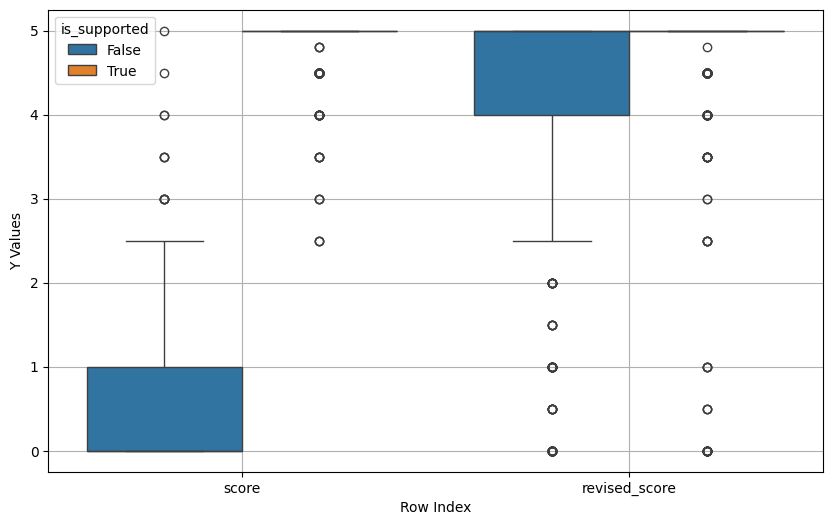

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_long,
    x='line_name',        # Use the reset index for the x-axis
    y='score_value',
    hue='is_supported',  # Different colors for 'line1_data' and 'line2_data'
    # style='is_supported'  # Different line styles for categories 'A' and 'B'
)

plt.xlabel('Row Index')
plt.ylabel('Y Values')
plt.legend(title='is_supported')
plt.grid(True)
plt.show()

# Autorater score histograms

Another way to view it.

As expected, the revised_score shifts all the scores to 5.0 since it's rewriting is_supported == False statements to True.

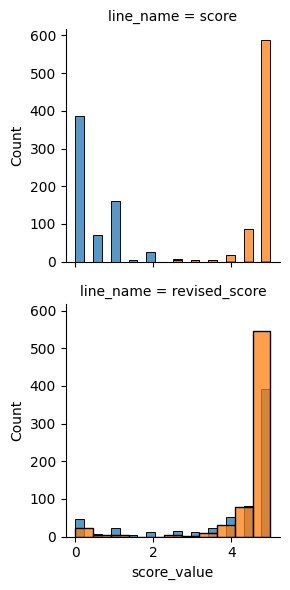

In [94]:
g = sns.FacetGrid(data=df_long, col='line_name', hue="is_supported", col_wrap=1)
g.map(sns.histplot, 'score_value')

## Stats

In [96]:
df_long.groupby(["line_name", "is_supported"])["score_value"].mean()

line_name      is_supported
revised_score  False           4.101051
               True            4.656410
score          False           0.469219
               True            4.882336
Name: score_value, dtype: float64

## Improvement of revised_score over score

Let's show that baseline gets a score of X then after revision we get a score of Y > X.
Where the score is based on this prompt.

In [140]:
df_results["revised_score_is_higher"] = df_results["revised_score"] > df_results["score"]

In [141]:
# df_results

This shows an overall improvement, irregardless of is_supported.

In [142]:
len(df_results[df_results["revised_score_is_higher"]])/len(df_results)

0.47733918128654973

Percentage same or improved for is_supported == True

8% improvement, which makes sense since the unrevised text was already is_supported == True to begin with.

In [143]:
len(df_results[df_results["revised_score_is_higher"] & df_results["is_supported"]])/len(df_results[df_results["is_supported"]])

0.07977207977207977

Percentage same or improved for is_supported == False.


This is what we really care about, which is the ability of critique-reviser agent to "correct" non-supported answers into supported answers.

In [144]:
len(df_results[df_results["revised_score_is_higher"] & ~df_results["is_supported"]])/len(df_results[df_results["is_supported"]])

0.8504273504273504

### Visual representation

This is harder to read and probably less useful

<Axes: xlabel='revised_score_is_higher', ylabel='Count'>

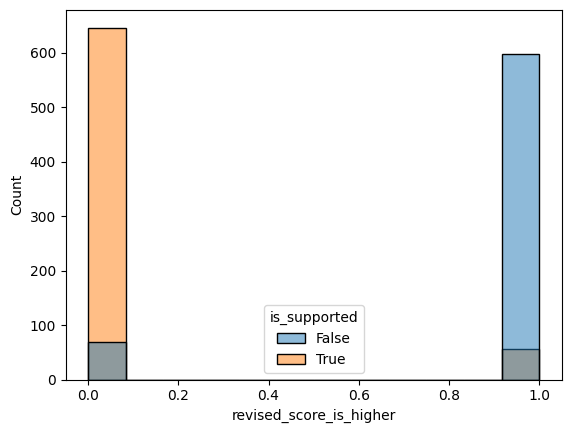

In [158]:
# g = sns.FacetGrid(data=df_results, hue="revised_score_is_higher")
# g.map(sns.histplot, 'is_supported')

sns.histplot(data=df_results, x="revised_score_is_higher", hue="is_supported")